# 🏠 Real Estate Price Prediction — Professional End-to-End ML Pipeline

**Author:** Real Estate ML Project  
**External Data:** `uszips.xlsx` — 33,782 U.S. ZIP codes with lat/lng, population, density  
**Target:** `price` (continuous regression)

---

## Pipeline Overview

| Stage | Description |
|-------|-------------|
| 1 | Business Understanding |
| 2 | Data Loading & External Merge |
| 3 | Initial Data Audit |
| 4 | Data Cleaning |
| 5 | Missing Value Analysis & Indicators |
| 6 | Date Processing |
| 7 | Hierarchical Imputation |
| 8 | EDA |
| 9 | Outlier Handling |
| 10 | Feature Engineering |
| 11 | Leakage Detection |
| 12 | Encoding & Scaling |
| 13 | Validation Strategy |
| 14 | Model Training & Tuning |
| 15 | Evaluation & Explainability |
| 16 | Save Artifacts |

---
## 0. Install Dependencies

In [29]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost optuna shap joblib openpyxl missingno

---
## 1. Imports & Configuration

In [30]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import missingno as msno
import joblib
import os

# Sklearn
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans

# Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# SHAP
import shap
shap.initjs()

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Output directory ────────────────────────────────────────────────────────
os.makedirs('artifacts', exist_ok=True)
print('✅ All imports successful')

✅ All imports successful


---
## 2. Data Loading

### 2A. Main Real Estate Dataset

> **Replace the path below** with your actual real estate CSV/Excel file.  
> Expected columns: `price`, `bed`, `bath`, `acre_lot`, `house_size`, `zip_code`, `city`, `state`, `prev_sold_date`, `street`, `full_address`

In [31]:
# ── Load main dataset ────────────────────────────────────────────────────────
MAIN_DATA_PATH = 'realtor-data.csv'   # Make sure this file exists

df = pd.read_csv(MAIN_DATA_PATH, low_memory=False)

# ── CRITICAL: Fix zip_code format in main dataset ───────────────────────────
df['zip_code'] = (
    df['zip_code']
    .astype(str)                    # Convert everything to string
    .str.strip()
    .str.replace(r'\.0$', '', regex=True)   # Remove .0 from floats
    .str.zfill(5)                   # Pad with leading zeros to 5 digits
)

print('Main dataset ZIP sample:', df['zip_code'].head(10).tolist())
print(f'Main dataset unique ZIPs: {df["zip_code"].nunique():,}')

Main dataset ZIP sample: ['00601', '00601', '00795', '00731', '00680', '00612', '00639', '00731', '00730', '00670']
Main dataset unique ZIPs: 22,083


### 2B. Load External ZIP Code Dataset (`uszips.xlsx`)

**Source:** `uszips.xlsx` — 33,782 U.S. ZIP codes  
**Available fields:** `zip`, `lat`, `lng`, `city`, `state_id`, `state_name`, `population`, `density`, `county_name`, `timezone`

In [32]:
# ── Load uszips.xlsx ─────────────────────────────────────────────────────────
zip_df = pd.read_excel('uszips.xlsx', dtype={'zip': str})

# Standardize ZIP in lookup table
zip_df['zip_code'] = (
    zip_df['zip']
    .astype(str)
    .str.strip()
    .str.zfill(5)
)

# Keep useful columns
ZIP_COLS = ['zip_code', 'lat', 'lng', 'population', 'density',
            'county_name', 'timezone', 'state_name']

zip_df = zip_df[ZIP_COLS].copy()
zip_df.rename(columns={
    'population': 'zip_population',
    'density': 'zip_density',
    'state_name': 'state_full'
}, inplace=True)

zip_df = zip_df.drop_duplicates(subset='zip_code')

print('ZIP lookup sample:', zip_df['zip_code'].head(5).tolist())
print(f'ZIP lookup table shape: {zip_df.shape}')

ZIP lookup sample: ['00601', '00602', '00603', '00606', '00610']
ZIP lookup table shape: (33782, 8)


### 2C. Merge Main Dataset with ZIP Enrichment

In [33]:
rows_before = len(df)

df = df.merge(zip_df, on='zip_code', how='left')

print(f'Rows before merge : {rows_before:,}')
print(f'Rows after merge  : {len(df):,}')
print(f'ZIP match rate    : {df["lat"].notna().mean():.2%}')
print(f'Rows with lat/lng : {df["lat"].notna().sum():,}')

# Debug top unmatched ZIPs
if df['lat'].isna().sum() > 0:
    print("\nTop 10 unmatched ZIP codes:")
    print(df[df['lat'].isna()]['zip_code'].value_counts().head(10))

Rows before merge : 974,882
Rows after merge  : 974,882
ZIP match rate    : 99.90%
Rows with lat/lng : 973,915

Top 10 unmatched ZIP codes:
zip_code
00nan    151
22530     29
36304     28
35631     16
38649     15
99999     14
11111     14
34755     13
65038     11
12541     10
Name: count, dtype: int64


---
## 3. Initial Data Audit

In [34]:
# ── Shape & Dtypes ────────────────────────────────────────────────────────────
print('='*60)
print(f'SHAPE:  {df.shape[0]:,} rows × {df.shape[1]} columns')
print('='*60)
print('\nDTYPES:')
print(df.dtypes.value_counts())
print('\nDETAIL:')
print(df.dtypes)

SHAPE:  974,882 rows × 19 columns

DTYPES:
float64    11
object      8
Name: count, dtype: int64

DETAIL:
brokered_by       float64
status             object
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city               object
state              object
zip_code           object
house_size        float64
prev_sold_date     object
lat               float64
lng               float64
zip_population    float64
zip_density       float64
county_name        object
timezone           object
state_full         object
dtype: object


In [35]:
# ── Missing Value Report ──────────────────────────────────────────────────────
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct'  : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)
missing = missing[missing['missing_count'] > 0]

print('MISSING VALUE REPORT')
print('='*40)
print(missing.to_string())

MISSING VALUE REPORT
                missing_count  missing_pct
prev_sold_date         507384        52.05
house_size             340334        34.91
bath                   298307        30.60
bed                    285576        29.29
acre_lot               171613        17.60
street                   5216         0.54
zip_population           1826         0.19
zip_density              1826         0.19
price                    1032         0.11
lng                       967         0.10
brokered_by              1003         0.10
state_full                967         0.10
county_name               967         0.10
timezone                  967         0.10
lat                       967         0.10
city                      823         0.08
state                       7         0.00


In [36]:
# ── Duplicate Report ─────────────────────────────────────────────────────────
dup_cols = [c for c in ['street', 'zip_code', 'price', 'house_size'] if c in df.columns]
n_dups = df.duplicated(subset=dup_cols).sum()
print(f'Exact duplicates (all cols)  : {df.duplicated().sum():,}')
print(f'Duplicates on {dup_cols} : {n_dups:,}')

Exact duplicates (all cols)  : 0
Duplicates on ['street', 'zip_code', 'price', 'house_size'] : 5,274


In [37]:
# ── Summary Statistics ────────────────────────────────────────────────────────
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brokered_by,973879.0,NaN,NaN,NaN,51805.216815,30442.357906,0.0,23634.0,52628.0,78903.0,110141.0
status,974882,2,for_sale,960108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,973850.0,NaN,NaN,NaN,483723.377668,2870193.652614,0.0,120000.0,279000.0,486812.5,2147483600.0
bed,689306.0,NaN,NaN,NaN,3.302947,1.619172,1.0,3.0,3.0,4.0,473.0
bath,676575.0,NaN,NaN,NaN,2.53533,1.703224,1.0,2.0,2.0,3.0,752.0
acre_lot,803269.0,NaN,NaN,NaN,15.370459,764.454116,0.0,0.18,0.35,1.25,100000.0
street,969666.0,NaN,NaN,NaN,1053979.895068,604670.625664,4.0,531465.25,1063106.5,1596573.5,2001357.0
city,974059,15025,Chicago,12688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,974875,48,Florida,163840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,974882,22083,33993,1681,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# ── Unique Category Counts ────────────────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col:30s}  unique={df[col].nunique():,}  top={df[col].mode()[0] if df[col].notna().any() else "N/A"!r}')

status                          unique=2  top='for_sale'
city                            unique=15,025  top='Chicago'
state                           unique=48  top='Florida'
zip_code                        unique=22,083  top='33993'
prev_sold_date                  unique=13,745  top='2022-04-29'
county_name                     unique=1,460  top='Cook'
timezone                        unique=24  top='America/New_York'
state_full                      unique=47  top='Florida'


---
## 4. Data Cleaning

In [39]:
rows_start = len(df)

# ── Remove invalid rows ───────────────────────────────────────────────────────
if 'price'      in df.columns: df = df[df['price']      > 0]
if 'house_size' in df.columns: df = df[df['house_size'] > 0]
if 'bath'       in df.columns: df = df[df['bath']       >= 0]
if 'bed'        in df.columns: df = df[df['bed']        >= 0]
if 'acre_lot'   in df.columns: df = df[df['acre_lot']   >= 0]

print(f'Rows removed (invalid values): {rows_start - len(df):,}')

Rows removed (invalid values): 490,951


In [40]:
# ── Remove duplicates ─────────────────────────────────────────────────────────
dup_cols = [c for c in ['street', 'zip_code', 'price', 'house_size'] if c in df.columns]
rows_before_dup = len(df)
df = df.drop_duplicates(subset=dup_cols, keep='first')
print(f'Rows removed (duplicates)    : {rows_before_dup - len(df):,}')

Rows removed (duplicates)    : 487


In [41]:
# ── Standardize formats ───────────────────────────────────────────────────────
if 'state' in df.columns:
    df['state'] = df['state'].astype(str).str.strip().str.lower()
if 'city' in df.columns:
    df['city'] = df['city'].astype(str).str.strip().str.lower()
if 'street' in df.columns:
    df['street'] = df['street'].astype(str).str.strip().str.lower()

# Ensure zip_code is string
df['zip_code'] = df['zip_code'].astype(str).str.zfill(5)

print(f'Final clean shape: {df.shape}')
df.head(3)

Final clean shape: (483444, 19)


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date,lat,lng,zip_population,zip_density,county_name,timezone,state_full
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,adjuntas,puerto rico,00601,920.0,NaN,18.18027,-66.75266,16669.0,99.9,Adjuntas,America/Puerto_Rico,Puerto Rico
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,adjuntas,puerto rico,00601,1527.0,NaN,18.18027,-66.75266,16669.0,99.9,Adjuntas,America/Puerto_Rico,Puerto Rico
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,juana diaz,puerto rico,00795,748.0,NaN,18.05128,-66.49485,43367.0,280.3,Juana Díaz,America/Puerto_Rico,Puerto Rico


---
## 5. Missing Value Analysis & Missing Indicators

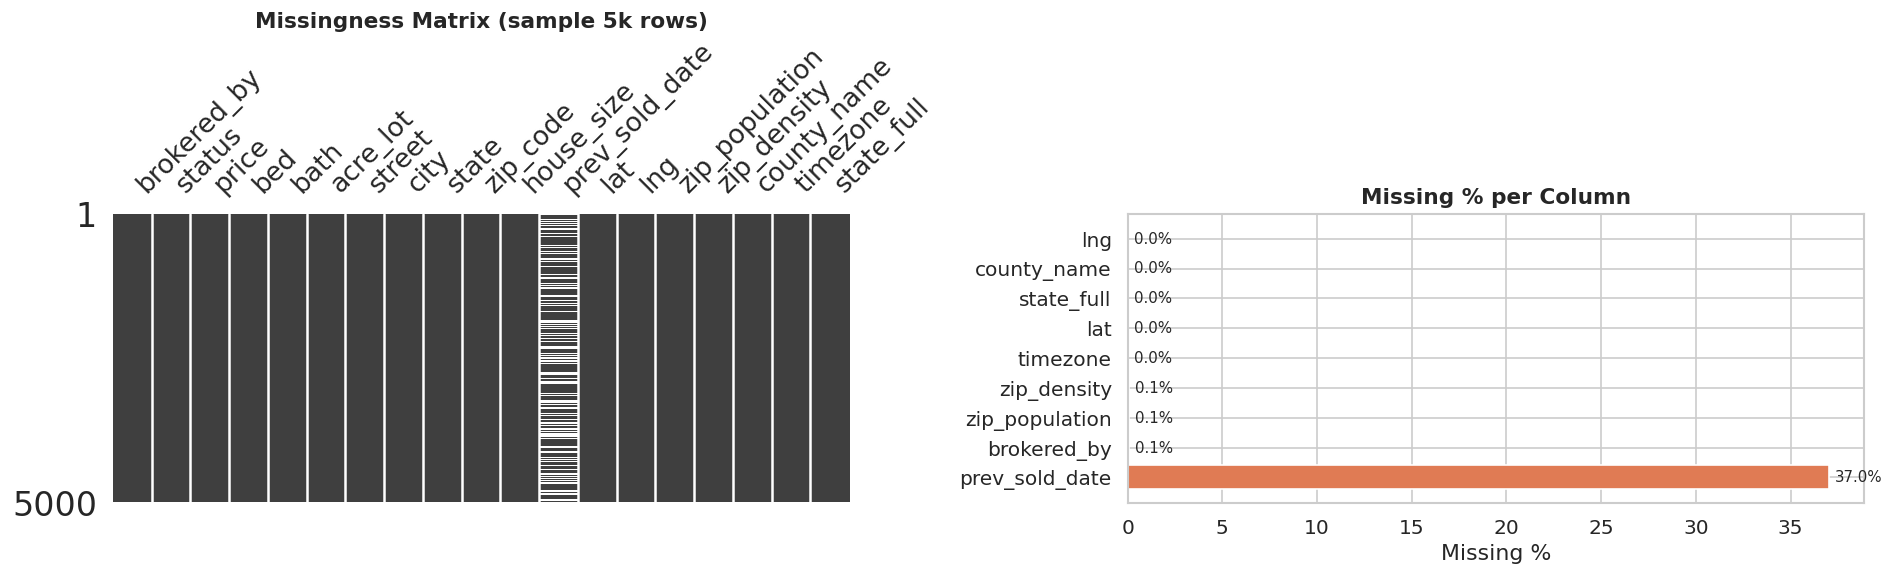

In [42]:
# ── Visualize missingness ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

msno.matrix(df.sample(min(5000, len(df)), random_state=RANDOM_STATE), ax=axes[0], sparkline=False)
axes[0].set_title('Missingness Matrix (sample 5k rows)', fontsize=13, fontweight='bold')

miss_pct = df.isnull().mean().sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
axes[1].barh(miss_pct.index, miss_pct.values * 100, color='#E07B54')
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing % per Column', fontsize=13, fontweight='bold')
for i, v in enumerate(miss_pct.values):
    axes[1].text(v * 100 + 0.3, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [43]:
# ── Create missing indicators BEFORE imputation ───────────────────────────────
INDICATOR_COLS = [c for c in ['house_size', 'acre_lot', 'bed', 'bath'] if c in df.columns]

for col in INDICATOR_COLS:
    df[f'{col}_was_missing'] = df[col].isnull().astype(int)

created = [f'{c}_was_missing' for c in INDICATOR_COLS]
print(f'Missing indicator columns created: {created}')
print(df[created].sum())

Missing indicator columns created: ['house_size_was_missing', 'acre_lot_was_missing', 'bed_was_missing', 'bath_was_missing']
house_size_was_missing    0
acre_lot_was_missing      0
bed_was_missing           0
bath_was_missing          0
dtype: int64


---
## 6. Date Processing

In [44]:
# ── Parse prev_sold_date ──────────────────────────────────────────────────────
if 'prev_sold_date' in df.columns:
    df['prev_sold_date'] = pd.to_datetime(df['prev_sold_date'], errors='coerce')

    reference_date = pd.Timestamp('2024-01-01')
    df['years_since_sold'] = ((reference_date - df['prev_sold_date']).dt.days / 365.25).clip(lower=0)
    df['has_been_sold']    = df['prev_sold_date'].notna().astype(int)
    df['sold_month']       = df['prev_sold_date'].dt.month
    df['sold_year']        = df['prev_sold_date'].dt.year

    print('Date features created: years_since_sold, has_been_sold, sold_month, sold_year')
    print(df[['years_since_sold', 'has_been_sold', 'sold_month', 'sold_year']].describe())
else:
    print('prev_sold_date not found — skipping date processing')

Date features created: years_since_sold, has_been_sold, sold_month, sold_year
       years_since_sold  has_been_sold     sold_month      sold_year
count     304484.000000  483444.000000  304484.000000  304484.000000
mean          11.546035       0.629823       6.587039    2011.949396
std            9.549637       0.482853       3.296093       9.563007
min            0.000000       0.000000       1.000000    1901.000000
25%            4.076660       0.000000       4.000000    2006.000000
50%            8.172485       1.000000       7.000000    2015.000000
75%           17.535934       1.000000       9.000000    2019.000000
max          122.997947       1.000000      12.000000    2026.000000


---
## 7. Hierarchical Missing Value Imputation

Strategy: `zip_code → city → state → global`  
- Discrete (`bed`, `bath`): **mode**  
- Continuous (`house_size`, `acre_lot`): **median**

In [45]:
def hierarchical_impute(df, col, method='median', levels=None):
    """
    Impute `col` using a hierarchy of groupby levels.
    method: 'median' or 'mode'
    levels: list of columns to group by in order, e.g. ['zip_code','city','state']
    Falls back to global stat if all levels fail.
    """
    if levels is None:
        levels = [c for c in ['zip_code', 'city', 'state'] if c in df.columns]

    filled = df[col].copy()
    mask   = filled.isnull()

    for level in levels:
        if level not in df.columns or mask.sum() == 0:
            break
        if method == 'median':
            lookup = df.groupby(level)[col].median()
        else:  # mode
            lookup = df.groupby(level)[col].agg(lambda x: x.mode().iloc[0] if x.notna().any() else np.nan)

        fill_vals = df.loc[mask, level].map(lookup)
        filled.loc[mask] = fill_vals.values
        mask = filled.isnull()

    # Final fallback: global stat
    if mask.sum() > 0:
        global_val = df[col].median() if method == 'median' else df[col].mode().iloc[0]
        filled.fillna(global_val, inplace=True)

    return filled


# ── Impute discrete features ──────────────────────────────────────────────────
for col in ['bed', 'bath']:
    if col in df.columns and df[col].isnull().any():
        before = df[col].isnull().sum()
        df[col] = hierarchical_impute(df, col, method='mode')
        print(f'{col:15s} → imputed {before:,} nulls (mode, hierarchical)')

# ── Impute continuous features ────────────────────────────────────────────────
for col in ['house_size', 'acre_lot']:
    if col in df.columns and df[col].isnull().any():
        before = df[col].isnull().sum()
        df[col] = hierarchical_impute(df, col, method='median')
        print(f'{col:15s} → imputed {before:,} nulls (median, hierarchical)')

print(f'\nRemaining nulls in core features: {df[["bed","bath","house_size","acre_lot"]].isnull().sum().sum()}')


Remaining nulls in core features: 0


---
## 8. Exploratory Data Analysis (EDA)

### 8A. Target Variable Analysis

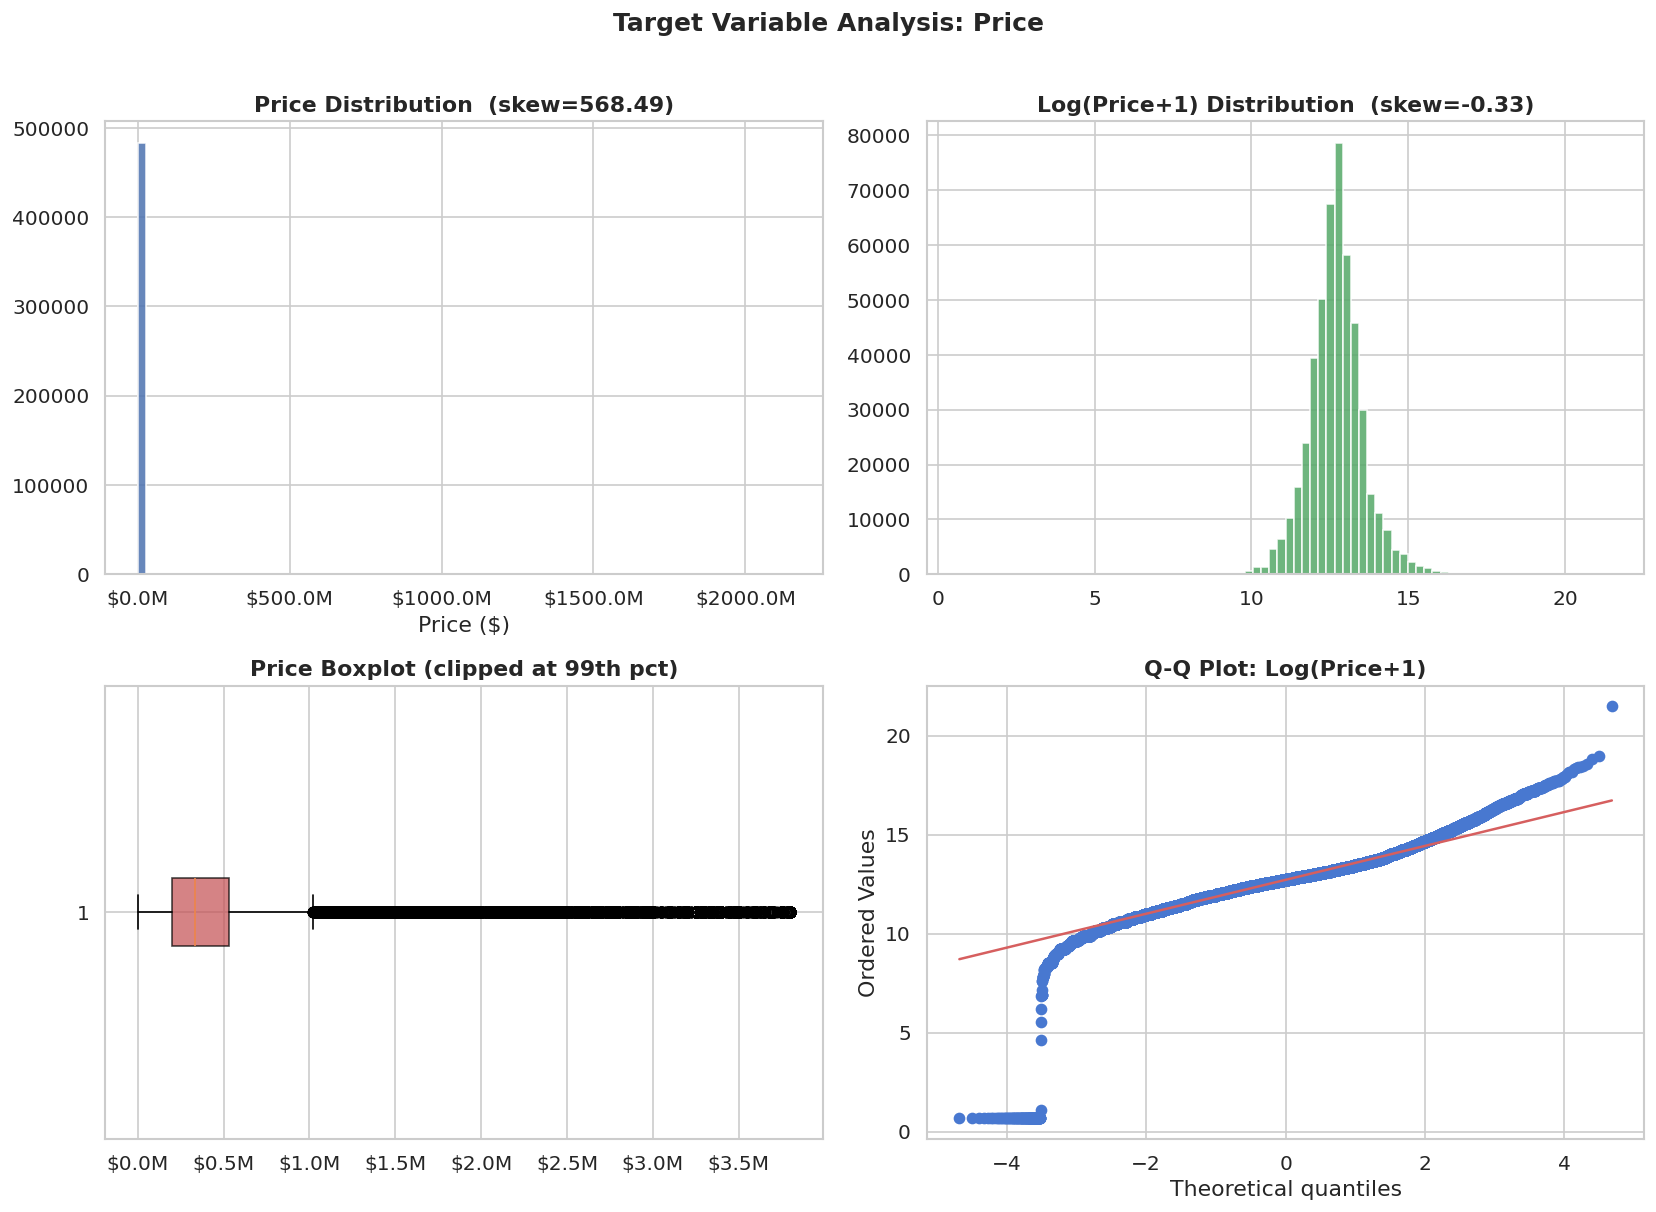

Skewness : 568.486
Kurtosis : 368351.361
Min      : $1
Median   : $333,990
Mean     : $527,982
Max      : $2,147,483,600


In [46]:
price = df['price'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0,0].hist(price, bins=80, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0,0].set_title(f'Price Distribution  (skew={price.skew():.2f})', fontweight='bold')
axes[0,0].set_xlabel('Price ($)'); axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

# Log histogram
log_price = np.log1p(price)
axes[0,1].hist(log_price, bins=80, color='#55A868', edgecolor='white', alpha=0.85)
axes[0,1].set_title(f'Log(Price+1) Distribution  (skew={log_price.skew():.2f})', fontweight='bold')

# Boxplot
axes[1,0].boxplot(price.clip(upper=price.quantile(0.99)), vert=False, patch_artist=True,
                  boxprops=dict(facecolor='#C44E52', alpha=0.7))
axes[1,0].set_title('Price Boxplot (clipped at 99th pct)', fontweight='bold')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

# Q-Q plot
stats.probplot(log_price, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot: Log(Price+1)', fontweight='bold')

plt.suptitle('Target Variable Analysis: Price', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Skewness : {price.skew():.3f}')
print(f'Kurtosis : {price.kurtosis():.3f}')
print(f'Min      : ${price.min():,.0f}')
print(f'Median   : ${price.median():,.0f}')
print(f'Mean     : ${price.mean():,.0f}')
print(f'Max      : ${price.max():,.0f}')

### 8B. Numerical Feature Distributions

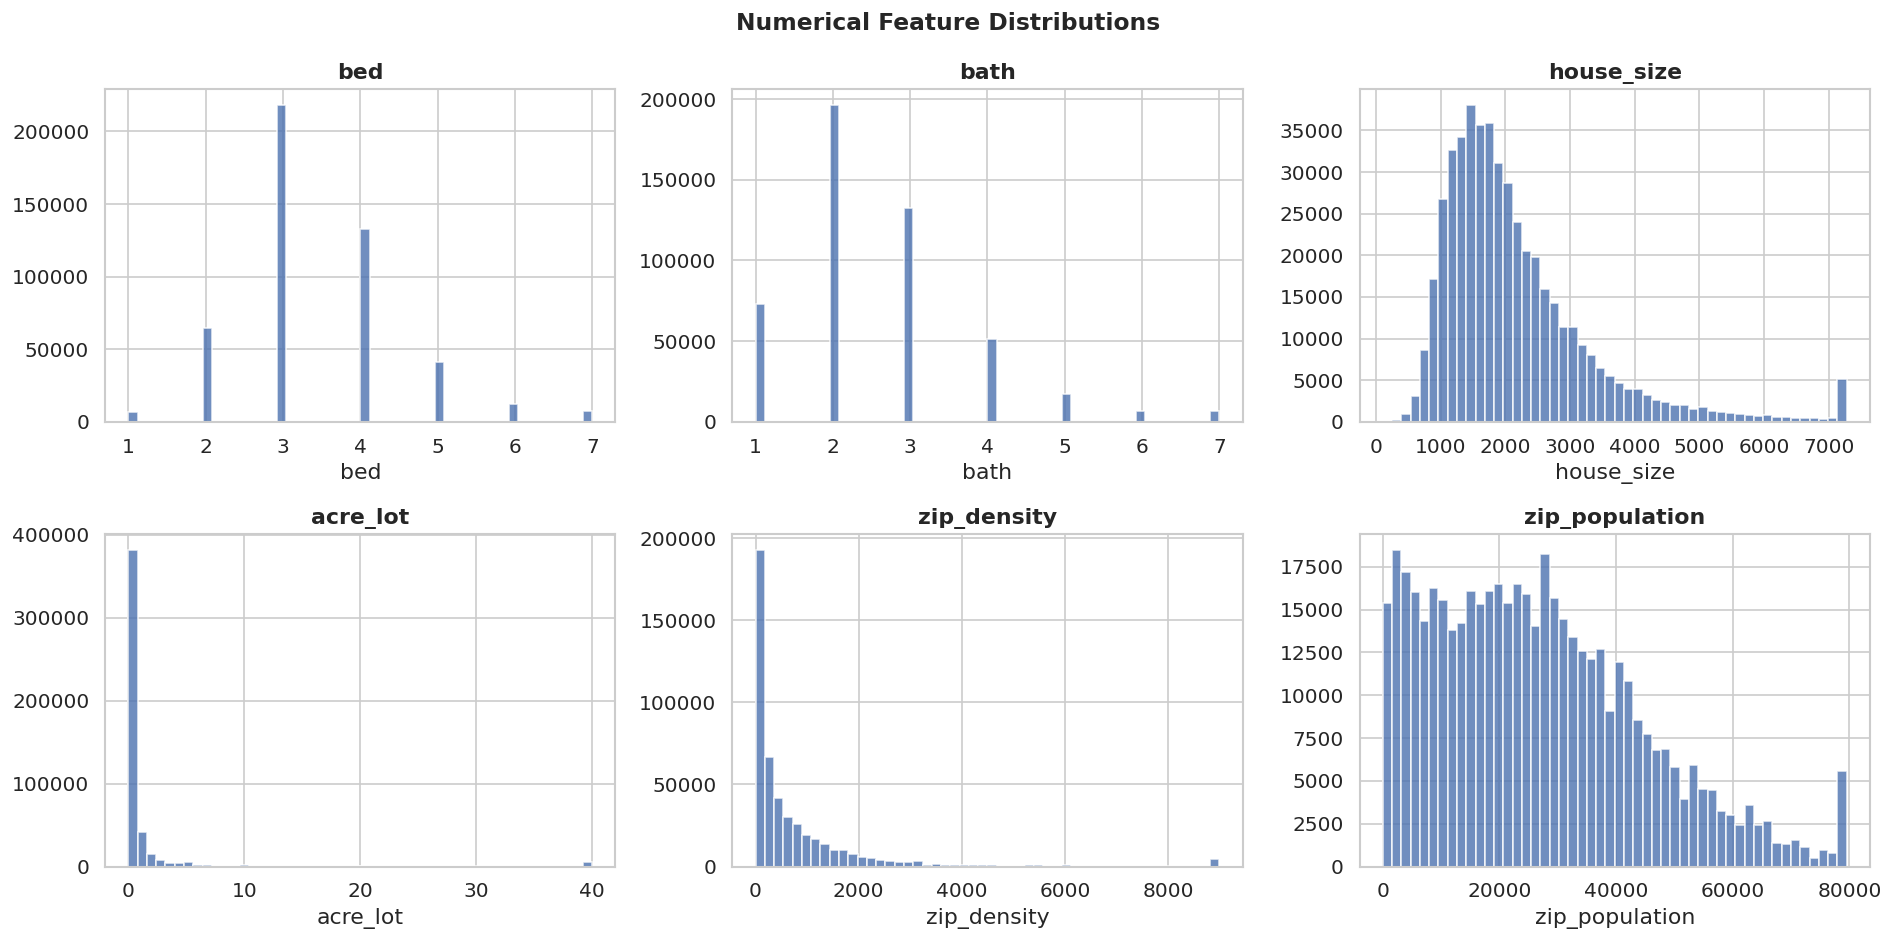

In [47]:
num_cols = [c for c in ['bed', 'bath', 'house_size', 'acre_lot',
                         'zip_density', 'zip_population'] if c in df.columns]

fig, axes = plt.subplots(2, len(num_cols)//2 + len(num_cols)%2,
                         figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna().clip(upper=df[col].quantile(0.99))
    axes[i].hist(data, bins=50, color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8C. Geographic Distribution of Listings

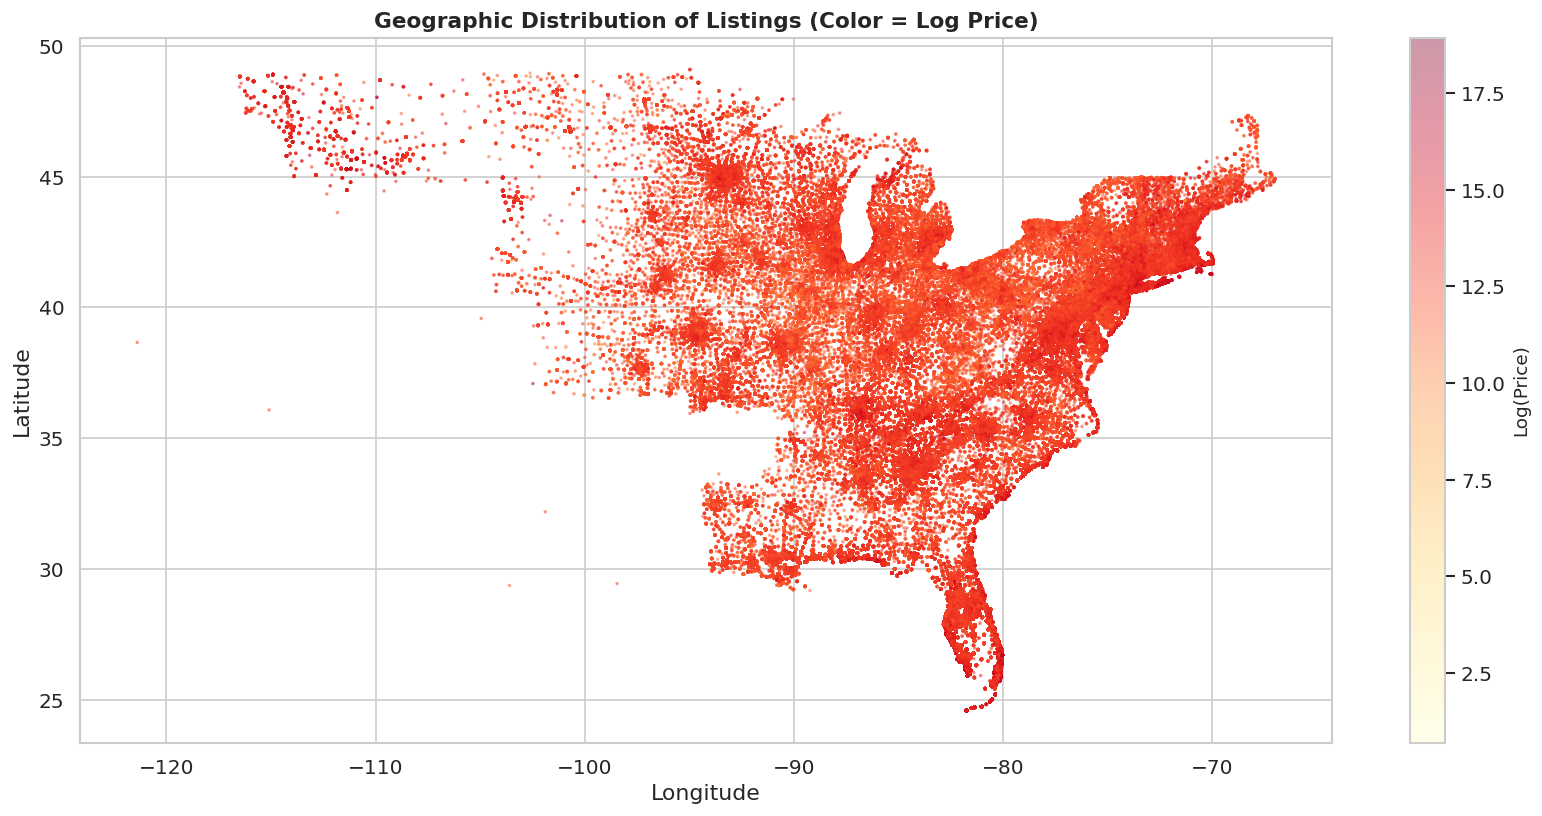

In [48]:
if 'lat' in df.columns and 'lng' in df.columns:
    geo = df.dropna(subset=['lat', 'lng'])
    # Filter continental US
    geo = geo[(geo['lat'].between(24, 50)) & (geo['lng'].between(-125, -65))]

    plt.figure(figsize=(14, 7))
    scatter = plt.scatter(
        geo['lng'], geo['lat'],
        c=np.log1p(geo['price']), cmap='YlOrRd',
        s=1.5, alpha=0.4
    )
    cbar = plt.colorbar(scatter)
    cbar.set_label('Log(Price)', fontsize=11)
    plt.title('Geographic Distribution of Listings (Color = Log Price)', fontweight='bold', fontsize=13)
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()
else:
    print('lat/lng not available — skipping geographic plot')

### 8D. Correlation Heatmap

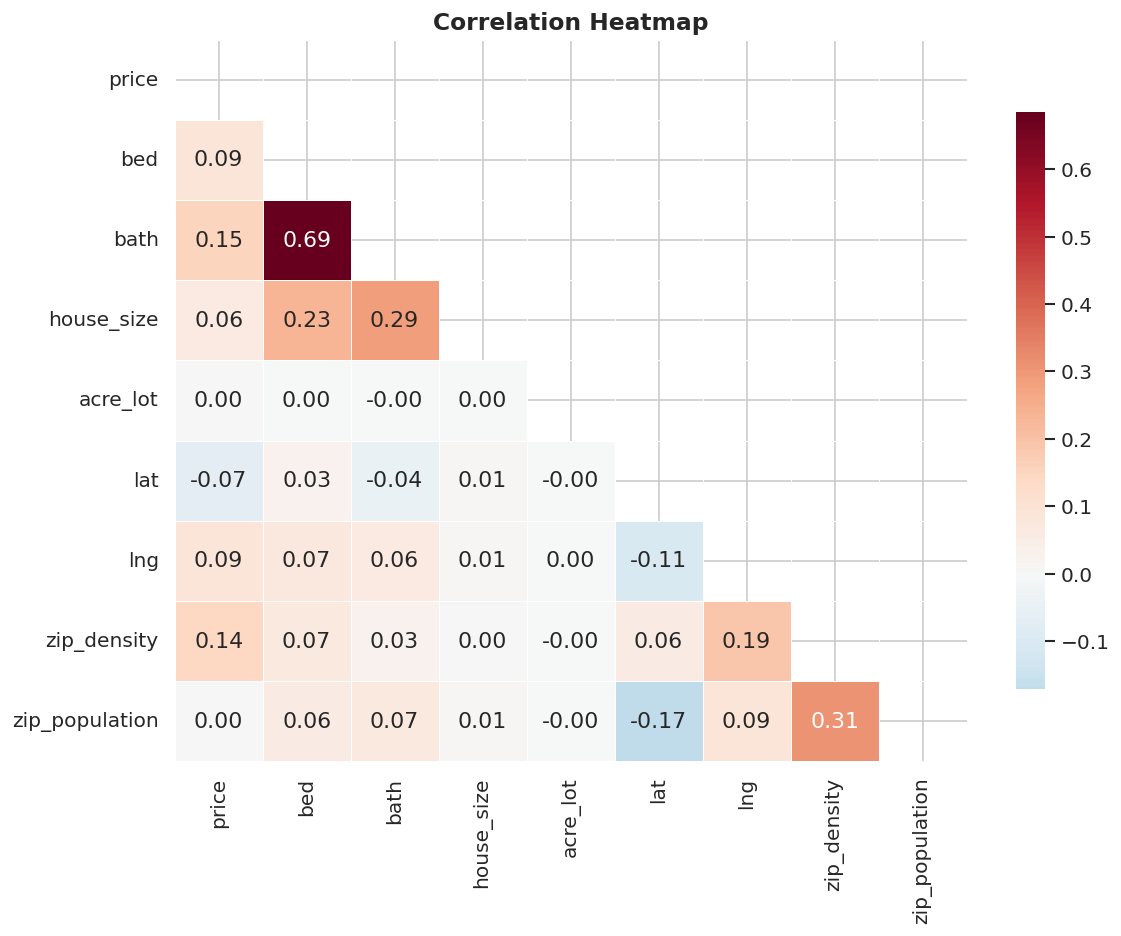

In [49]:
corr_cols = [c for c in ['price', 'bed', 'bath', 'house_size', 'acre_lot',
                          'lat', 'lng', 'zip_density', 'zip_population'] if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8E. Price by State (Top 15)

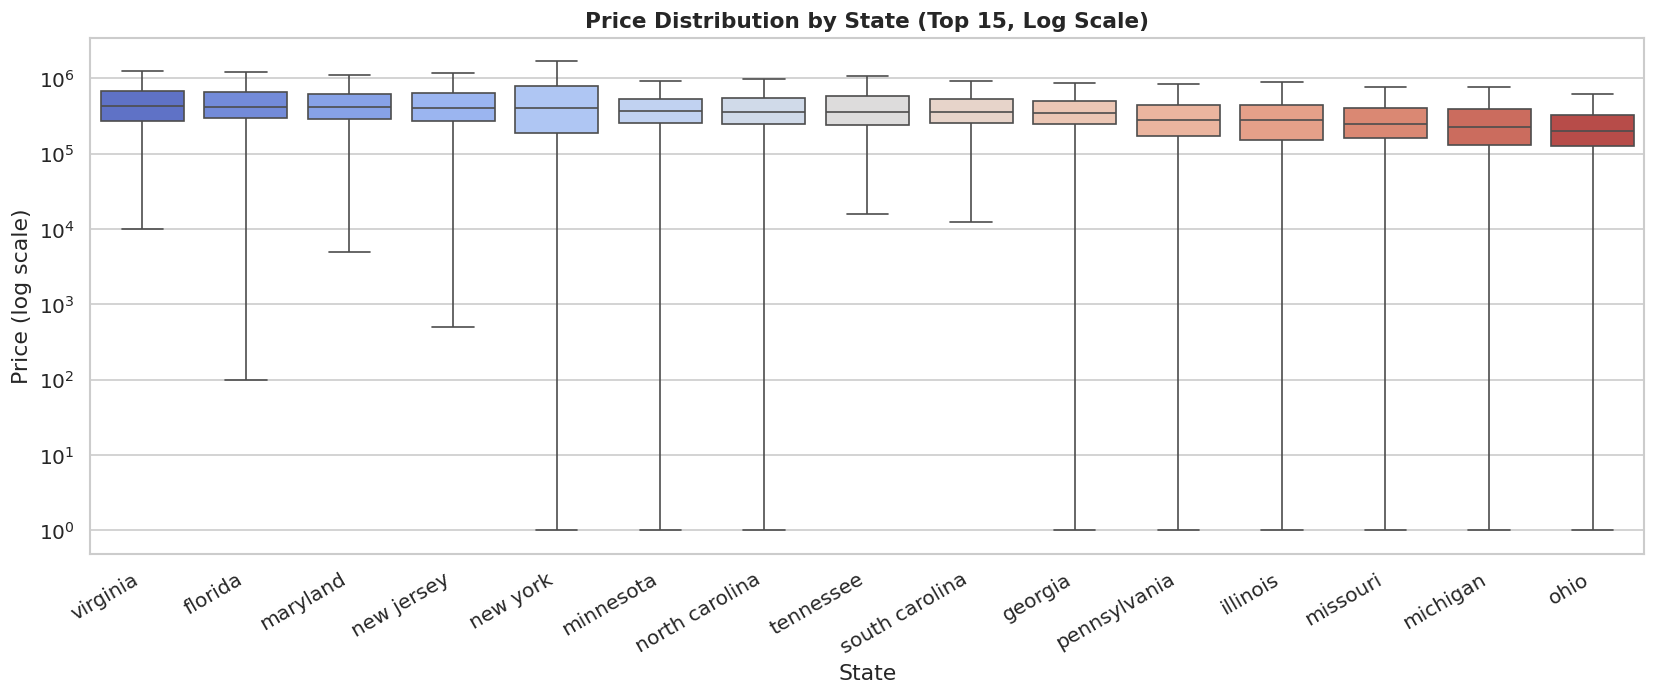

In [50]:
state_col = 'state' if 'state' in df.columns else 'state_full'

if state_col in df.columns:
    top_states = df[state_col].value_counts().nlargest(15).index
    plot_df = df[df[state_col].isin(top_states)]

    plt.figure(figsize=(14, 6))
    order = plot_df.groupby(state_col)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=plot_df, x=state_col, y='price', order=order,
                palette='coolwarm', showfliers=False)
    plt.yscale('log')
    plt.title('Price Distribution by State (Top 15, Log Scale)', fontweight='bold', fontsize=13)
    plt.xlabel('State'); plt.ylabel('Price (log scale)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

---
## 9. Outlier Handling

Strategy: **Per-state IQR clipping** for `price`, `house_size`, `acre_lot`

In [51]:
def per_group_iqr_clip(df, col, group_col, multiplier=3.0):
    """
    Clip `col` using IQR computed per `group_col`.
    Uses a wide multiplier (3.0) to preserve legitimate luxury/rural outliers.
    """
    clipped = df[col].copy()
    if group_col not in df.columns:
        q1  = df[col].quantile(0.25)
        q3  = df[col].quantile(0.75)
        iqr = q3 - q1
        clipped = clipped.clip(lower=q1 - multiplier*iqr, upper=q3 + multiplier*iqr)
        return clipped

    for group, idx in df.groupby(group_col).groups.items():
        vals = df.loc[idx, col]
        q1   = vals.quantile(0.25)
        q3   = vals.quantile(0.75)
        iqr  = q3 - q1
        lo   = q1 - multiplier * iqr
        hi   = q3 + multiplier * iqr
        clipped.loc[idx] = vals.clip(lower=lo, upper=hi)

    return clipped


state_col = 'state' if 'state' in df.columns else 'state_full'
CLIP_COLS  = [c for c in ['price', 'house_size', 'acre_lot'] if c in df.columns]

for col in CLIP_COLS:
    before_std = df[col].std()
    df[col]    = per_group_iqr_clip(df, col, group_col=state_col)
    after_std  = df[col].std()
    print(f'{col:15s}  std: {before_std:,.0f} → {after_std:,.0f}')

price            std: 3,305,095 → 3,112,418
house_size       std: 3,714 → 1,120
acre_lot         std: 873 → 1


---
## 10. Feature Engineering

In [52]:
# ── Structural features ───────────────────────────────────────────────────────
if all(c in df.columns for c in ['bed', 'bath']):
    df['total_rooms'] = df['bed'] + df['bath']
    df['bed_to_bath_ratio'] = (df['bed'] / df['bath'].replace(0, np.nan)).fillna(0)

if all(c in df.columns for c in ['house_size', 'bed']):
    df['sqft_per_bedroom'] = (df['house_size'] / df['bed'].replace(0, np.nan)).fillna(0)

# ── Interaction features ──────────────────────────────────────────────────────
if all(c in df.columns for c in ['house_size', 'bed']):
    df['size_bed_interaction']  = df['house_size'] * df['bed']
if all(c in df.columns for c in ['house_size', 'bath']):
    df['size_bath_interaction'] = df['house_size'] * df['bath']

# ── Log features ──────────────────────────────────────────────────────────────
if 'house_size' in df.columns:
    df['log_house_size'] = np.log1p(df['house_size'])
if 'acre_lot' in df.columns:
    df['log_acre_lot'] = np.log1p(df['acre_lot'])
# NOTE: log_price created separately for EDA only; not used as model feature

# ── Luxury flags ──────────────────────────────────────────────────────────────
if 'house_size' in df.columns:
    size_thresh = df['house_size'].quantile(0.85)
    df['is_large_home'] = (df['house_size'] >= size_thresh).astype(int)
if 'acre_lot' in df.columns:
    lot_thresh = df['acre_lot'].quantile(0.85)
    df['is_large_lot'] = (df['acre_lot'] >= lot_thresh).astype(int)

# Luxury score = weighted sum of size + lot + bath count
luxury_components = []
if 'is_large_home' in df.columns: luxury_components.append(df['is_large_home'])
if 'is_large_lot'  in df.columns: luxury_components.append(df['is_large_lot'])
if 'bath'          in df.columns: luxury_components.append((df['bath'] >= 3).astype(int))
if luxury_components:
    df['luxury_score'] = sum(luxury_components)

print('Structural, interaction, log, and luxury features created ✅')

Structural, interaction, log, and luxury features created ✅


In [53]:
# ── Geographic features (Robust Version) ─────────────────────────────────────
if 'lat' in df.columns and 'lng' in df.columns:

    # Clean any remaining invalid geo
    geo_mask = df['lat'].notna() & df['lng'].notna()
    geo_valid = df[geo_mask][['lat', 'lng']]

    print(f'Valid geo records for clustering: {len(geo_valid):,}')

    # --- Distance to state center ---
    state_col = 'state' if 'state' in df.columns else 'state_full'

    if state_col in df.columns:
        state_centers = df[geo_mask].groupby(state_col)[['lat', 'lng']].median()

        df = df.join(state_centers.rename(columns={'lat': 'state_lat_center',
                                                    'lng': 'state_lng_center'}),
                     on=state_col)

        df['dist_to_state_center'] = np.sqrt(
            (df['lat'] - df['state_lat_center'])**2 +
            (df['lng'] - df['state_lng_center'])**2
        )
        df.drop(columns=['state_lat_center', 'state_lng_center'], inplace=True, errors='ignore')
    else:
        df['dist_to_state_center'] = 0.0

    # --- Regional KMeans Cluster ---
    if len(geo_valid) >= 5:
        km = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
        cluster_labels = km.fit_predict(geo_valid)

        df.loc[geo_valid.index, 'regional_cluster'] = cluster_labels
        print(f'✅ Created 5 regional clusters')
    else:
        df['regional_cluster'] = -1
        print('⚠️ Not enough geo data for clustering')

    df['regional_cluster'] = df['regional_cluster'].fillna(-1).astype(int)

    # --- Location density ---
    if 'zip_density' in df.columns:
        df['location_density'] = np.log1p(df['zip_density'].fillna(0))
    else:
        df['location_density'] = 0.0

    print('Geographic features created successfully ✅')

else:
    print('lat/lng columns missing')
    df['regional_cluster'] = -1
    df['dist_to_state_center'] = 0.0
    df['location_density'] = 0.0

Valid geo records for clustering: 483,239
✅ Created 5 regional clusters
Geographic features created successfully ✅


In [54]:
# ── Socioeconomic features (from uszips.xlsx via merge) ───────────────────────
# zip_density and zip_population already merged earlier
# Derive population_density bucket
if 'zip_density' in df.columns:
    df['density_bucket'] = pd.qcut(df['zip_density'].fillna(0), q=5,
                                    labels=['rural','low','medium','high','urban'],
                                    duplicates='drop')

new_feats = [c for c in [
    'total_rooms','bed_to_bath_ratio','sqft_per_bedroom',
    'size_bed_interaction','size_bath_interaction',
    'log_house_size','log_acre_lot',
    'is_large_home','is_large_lot','luxury_score',
    'dist_to_state_center','regional_cluster','location_density',
    'density_bucket'
] if c in df.columns]

print(f'Total engineered features: {len(new_feats)}')
print(df[new_feats].head(3))

Total engineered features: 14
   total_rooms  bed_to_bath_ratio  sqft_per_bedroom  size_bed_interaction  \
0          5.0                1.5        306.666667                2760.0   
1          6.0                2.0        381.750000                6108.0   
2          3.0                2.0        374.000000                1496.0   

   size_bath_interaction  log_house_size  log_acre_lot  is_large_home  \
0                 1840.0        6.825460      0.113329              0   
1                 3054.0        7.331715      0.076961              0   
2                  748.0        6.618739      0.139762              0   

   is_large_lot  luxury_score  dist_to_state_center  regional_cluster  \
0             0             0              0.633818                 1   
1             0             0              0.633818                 1   
2             0             0              0.458325                 1   

   location_density density_bucket  
0          4.614130            low  
1

---
## 11. Leakage Detection

Remove any target-derived or future-data columns before training.

In [55]:
# ── Drop leakage columns ──────────────────────────────────────────────────────
LEAK_COLS = [
    'price_per_acre',    # derived from target
    'price_per_sqft',    # derived from target
    'log_price',         # IS the target
    'future_price',      # future data
    'sold_price',        # target proxy
]
drop_leak = [c for c in LEAK_COLS if c in df.columns]
df.drop(columns=drop_leak, inplace=True)
print(f'Leakage columns dropped: {drop_leak}')

# ── Sanity check: ensure price is not among features ─────────────────────────
assert 'price' in df.columns, 'Target column price not found!'
print('\n✅ Leakage check passed — price intact as target only')

Leakage columns dropped: []

✅ Leakage check passed — price intact as target only


---
## 12. Feature Encoding & Scaling

- **Low cardinality** (≤10 unique): `OneHotEncoder`  
- **High cardinality** (`zip_code`, `city`, `street`): **Target Encoding with CV**  
- **Numerical**: `RobustScaler`

In [56]:
from sklearn.model_selection import KFold

def target_encode_cv(df, col, target, n_splits=5, smoothing=10, random_state=42):
    """
    Cross-validated target encoding.
    Smooths toward global mean to prevent high-cardinality leakage.
    """
    encoded   = np.full(len(df), np.nan)
    global_mean = df[target].mean()
    kf        = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(df):
        train = df.iloc[train_idx]
        stats = train.groupby(col)[target].agg(['mean', 'count'])
        stats['smooth'] = (
            (stats['count'] * stats['mean'] + smoothing * global_mean)
            / (stats['count'] + smoothing)
        )
        encoded[val_idx] = df.iloc[val_idx][col].map(stats['smooth']).fillna(global_mean).values

    return encoded


# ── Identify column types ─────────────────────────────────────────────────────
TARGET       = 'price'
EXCLUDE_COLS = [TARGET, 'prev_sold_date', 'zip_code', 'city', 'street',
                'state_full', 'county_name', 'timezone']

HIGH_CARD_COLS = [c for c in ['zip_code', 'city', 'street'] if c in df.columns]
LOW_CARD_COLS  = [c for c in df.select_dtypes(include='object').columns
                  if c not in HIGH_CARD_COLS + EXCLUDE_COLS
                  and df[c].nunique() <= 10]
NUM_COLS       = [c for c in df.select_dtypes(include=[np.number]).columns
                  if c not in [TARGET] + [f'{x}_was_missing' for x in ['bed','bath','house_size','acre_lot']]]

print(f'High-cardinality (target enc) : {HIGH_CARD_COLS}')
print(f'Low-cardinality  (OHE)        : {LOW_CARD_COLS}')
print(f'Numerical (RobustScaler)      : {len(NUM_COLS)} cols')

High-cardinality (target enc) : ['zip_code', 'city', 'street']
Low-cardinality  (OHE)        : ['status']
Numerical (RobustScaler)      : 26 cols


In [57]:
# ── Apply target encoding to high-cardinality columns ────────────────────────
df_enc = df.copy()

for col in HIGH_CARD_COLS:
    new_col = f'{col}_te'
    df_enc[new_col] = target_encode_cv(df_enc, col, TARGET)
    print(f'Target-encoded: {col} → {new_col}')

# Add the new TE columns to numerical features
TE_COLS  = [f'{c}_te' for c in HIGH_CARD_COLS]
NUM_COLS = NUM_COLS + TE_COLS

Target-encoded: zip_code → zip_code_te
Target-encoded: city → city_te
Target-encoded: street → street_te


In [58]:
# ── One-hot encode low-cardinality columns ────────────────────────────────────
if LOW_CARD_COLS:
    df_enc = pd.get_dummies(df_enc, columns=LOW_CARD_COLS, drop_first=True)
    print(f'OHE applied to: {LOW_CARD_COLS}')
    print(f'Shape after OHE: {df_enc.shape}')

OHE applied to: ['status']
Shape after OHE: (483444, 43)


In [59]:
# ── Build final feature matrix ────────────────────────────────────────────────
ohe_new_cols = [c for c in df_enc.columns
                if any(c.startswith(base + '_') for base in LOW_CARD_COLS)]

MISS_IND_COLS = [c for c in df_enc.columns if c.endswith('_was_missing')]

FEATURE_COLS = sorted(set(
    NUM_COLS + ohe_new_cols + MISS_IND_COLS
) - set(EXCLUDE_COLS + [TARGET]))
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_enc.columns]

X = df_enc[FEATURE_COLS].copy()
y = df_enc[TARGET].copy()

# Drop rows where target is null
valid_mask = y.notna()
X, y = X[valid_mask], y[valid_mask]

# Fill remaining NaNs with median
X = X.fillna(X.median(numeric_only=True))

print(f'Feature matrix: {X.shape}')
print(f'Target series : {y.shape}')

Feature matrix: (483444, 33)
Target series : (483444,)


In [60]:
# ── RobustScaler on numeric features ─────────────────────────────────────────
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = X.copy()
X_scaled[FEATURE_COLS] = scaler.fit_transform(X[FEATURE_COLS])

print('RobustScaler fitted ✅')

RobustScaler fitted ✅


---
## 13. Train-Validation Strategy

**GroupKFold** grouped by `zip_code` → realistic geographic generalization

In [61]:
from sklearn.model_selection import GroupKFold

N_SPLITS = 5
gkf      = GroupKFold(n_splits=N_SPLITS)
groups   = df_enc.loc[valid_mask, 'zip_code'].values

def evaluate_model(model, X, y, groups, cv, label='Model'):
    """Run GroupKFold CV and return per-fold metrics."""
    r2_scores, mae_scores, rmse_scores, mape_scores = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups)):
        Xtr, Xval = X.iloc[train_idx], X.iloc[val_idx]
        ytr, yval = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(Xtr, ytr)
        preds = model.predict(Xval)

        r2_scores.append(r2_score(yval, preds))
        mae_scores.append(mean_absolute_error(yval, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(yval, preds)))
        mape_scores.append(np.mean(np.abs((yval - preds) / yval.clip(lower=1))) * 100)

    results = {
        'Model': label,
        'R2'  : np.mean(r2_scores),
        'MAE' : np.mean(mae_scores),
        'RMSE': np.mean(rmse_scores),
        'MAPE': np.mean(mape_scores),
        'R2_std': np.std(r2_scores),
    }
    return results, model

print(f'GroupKFold ({N_SPLITS} folds) ready — grouped by zip_code ✅')

GroupKFold (5 folds) ready — grouped by zip_code ✅


---
## 14. Baseline Model

In [62]:
baseline    = DummyRegressor(strategy='median')
res_base, _ = evaluate_model(baseline, X_scaled, y, groups, gkf, 'DummyRegressor (Median)')
print('Baseline results:')
for k, v in res_base.items():
    print(f'  {k:10s}: {v}' if isinstance(v, str) else f'  {k:10s}: {v:,.3f}')

Baseline results:
  Model     : DummyRegressor (Median)
  R2        : -0.060
  MAE       : 247,132.446
  RMSE      : 1,705,599.606
  MAPE      : 7,421.193
  R2_std    : 0.030


---
## 15. Model Training

In [63]:
models = {
    'Ridge'           : Ridge(alpha=10),
    'Lasso'           : Lasso(alpha=50, max_iter=5000),
    'RandomForest'    : RandomForestRegressor(n_estimators=200, max_depth=12,
                                              min_samples_leaf=5,
                                              n_jobs=-1, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                   learning_rate=0.05,
                                                   random_state=RANDOM_STATE),
    'XGBoost'         : XGBRegressor(n_estimators=300, max_depth=6,
                                     learning_rate=0.05, subsample=0.8,
                                     colsample_bytree=0.8, n_jobs=-1,
                                     random_state=RANDOM_STATE, verbosity=0),
    'LightGBM'        : LGBMRegressor(n_estimators=300, max_depth=6,
                                      learning_rate=0.05, subsample=0.8,
                                      n_jobs=-1, random_state=RANDOM_STATE,
                                      verbose=-1),
    'CatBoost'        : CatBoostRegressor(iterations=300, depth=6,
                                           learning_rate=0.05,
                                           random_seed=RANDOM_STATE,
                                           verbose=0),
}

all_results = [res_base]
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    res, fitted = evaluate_model(model, X_scaled, y, groups, gkf, name)
    all_results.append(res)
    trained_models[name] = fitted
    print(f'R²={res["R2"]:.3f}  MAE=${res["MAE"]:,.0f}  MAPE={res["MAPE"]:.1f}%')

results_df = pd.DataFrame(all_results).set_index('Model').round(3)
results_df

Training Ridge... R²=0.548  MAE=$142,025  MAPE=6962.7%
Training Lasso... R²=0.548  MAE=$141,971  MAPE=6957.9%
Training RandomForest... R²=-5.097  MAE=$113,585  MAPE=6573.1%
Training GradientBoosting... R²=-15.477  MAE=$110,558  MAPE=6559.6%
Training XGBoost... R²=-12.400  MAE=$111,195  MAPE=6540.3%
Training LightGBM... R²=-10.048  MAE=$118,757  MAPE=6537.5%
Training CatBoost... R²=-16.299  MAE=$120,551  MAPE=6675.4%


,R2,MAE,RMSE,MAPE,R2_std
Model,,,,,
DummyRegressor (Median),-0.060,247132.446,1705599.606,7421.193,0.030
Ridge,0.548,142024.587,1563116.316,6962.675,0.279
Lasso,0.548,141971.321,1563102.212,6957.859,0.279
RandomForest,-5.097,113585.145,2083664.613,6573.140,7.824
GradientBoosting,-15.477,110557.886,2149568.094,6559.634,32.160
XGBoost,-12.400,111195.011,2382570.080,6540.284,16.705
LightGBM,-10.048,118757.204,2355656.956,6537.496,14.176
CatBoost,-16.299,120550.912,2603725.115,6675.394,20.056


---
## 16. Hyperparameter Tuning with Optuna

Tune the best tree model (LightGBM).

In [64]:
# Use a single train/val split for fast tuning
from sklearn.model_selection import train_test_split

# Stratify by region for a representative split
Xtr, Xval, ytr, yval = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

def lgbm_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 150),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'n_jobs'          : -1,
        'random_state'    : RANDOM_STATE,
        'verbose'         : -1,
    }
    model = LGBMRegressor(**params)
    model.fit(Xtr, ytr)
    preds = model.predict(Xval)
    return np.sqrt(mean_squared_error(yval, preds))

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f'\nBest RMSE: ${study.best_value:,.0f}')
print('Best params:', study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]


Best RMSE: $302,811
Best params: {'n_estimators': 115, 'max_depth': 3, 'learning_rate': 0.011597857794097525, 'num_leaves': 112, 'subsample': 0.7761025258482941, 'colsample_bytree': 0.5166897921127279, 'min_child_samples': 48, 'reg_alpha': 0.006588530147501625, 'reg_lambda': 1.863992335708519}


In [ ]:
# ── Train tuned LightGBM on full training fold ────────────────────────────────
best_params = study.best_params
best_params.update({'n_jobs': -1, 'random_state': RANDOM_STATE, 'verbose': -1})

tuned_lgbm = LGBMRegressor(**best_params)
res_tuned, tuned_lgbm = evaluate_model(tuned_lgbm, X_scaled, y, groups, gkf, 'LightGBM (Tuned)')
all_results.append(res_tuned)

print(f'Tuned LightGBM  R²={res_tuned["R2"]:.3f}  MAE=${res_tuned["MAE"]:,.0f}  MAPE={res_tuned["MAPE"]:.1f}%')

---
## 17. Model Comparison

                             R2         MAE         RMSE      MAPE  R2_std
Model                                                                     
Lasso                     0.548  141971.321  1563102.212  6957.859   0.279
Ridge                     0.548  142024.587  1563116.316  6962.675   0.279
LightGBM (Tuned)          0.364  161767.275  1610660.382  8006.211   0.189
DummyRegressor (Median)  -0.060  247132.446  1705599.606  7421.193   0.030
RandomForest             -5.097  113585.145  2083664.613  6573.140   7.824
LightGBM                -10.048  118757.204  2355656.956  6537.496  14.176
XGBoost                 -12.400  111195.011  2382570.080  6540.284  16.705
GradientBoosting        -15.477  110557.886  2149568.094  6559.634  32.160
CatBoost                -16.299  120550.912  2603725.115  6675.394  20.056


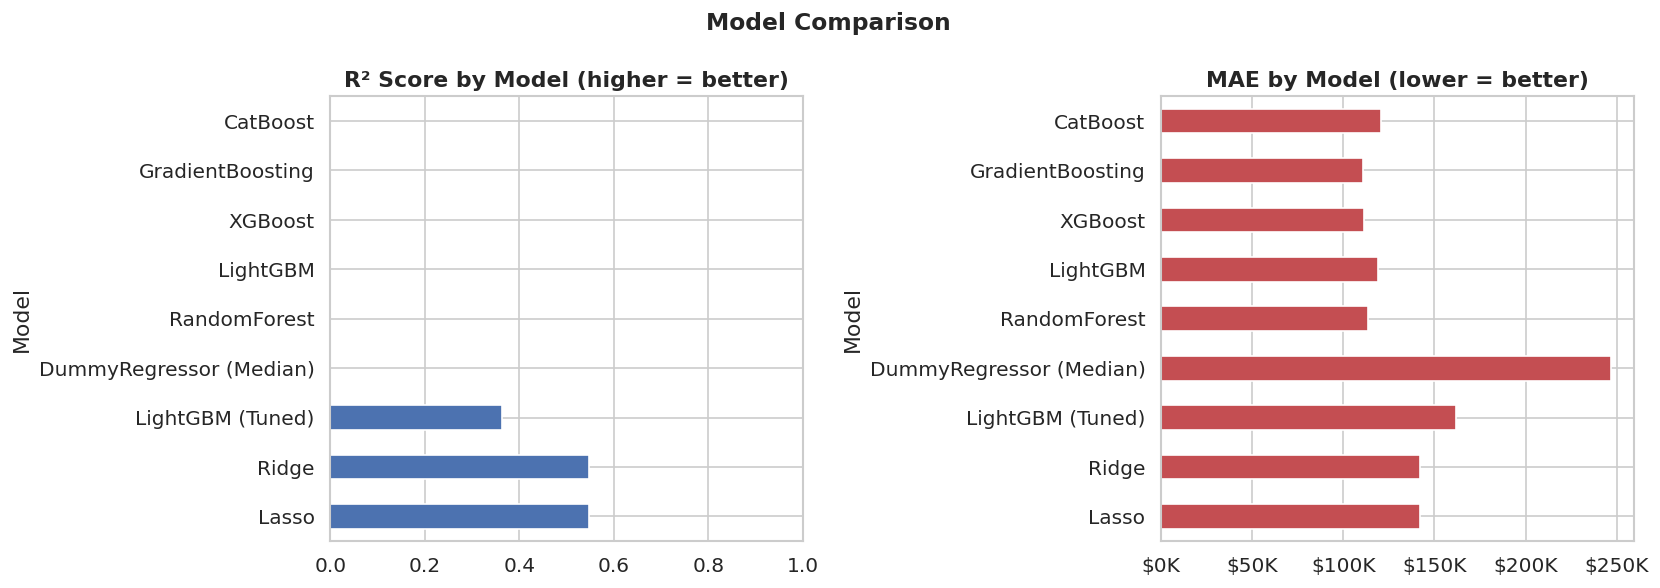

In [66]:
final_results = pd.DataFrame(all_results).set_index('Model').sort_values('R2', ascending=False)
print(final_results.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

final_results['R2'].plot(kind='barh', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('R² Score by Model (higher = better)', fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=0, color='black', linewidth=0.5)

final_results['MAE'].plot(kind='barh', ax=axes[1], color='#C44E52', edgecolor='white')
axes[1].set_title('MAE by Model (lower = better)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 18. Final Model Selection & Evaluation

In [ ]:
# ── Select best model ─────────────────────────────────────────────────────────
best_model_name = final_results['R2'].idxmax()
print(f'🏆 Best model: {best_model_name}')

# Refit on full data
if best_model_name == 'LightGBM (Tuned)':
    final_model = LGBMRegressor(**best_params)
elif best_model_name in trained_models:
    final_model = trained_models[best_model_name]
else:
    final_model = tuned_lgbm

final_model.fit(X_scaled, y)
print('Final model fitted on full dataset ✅')

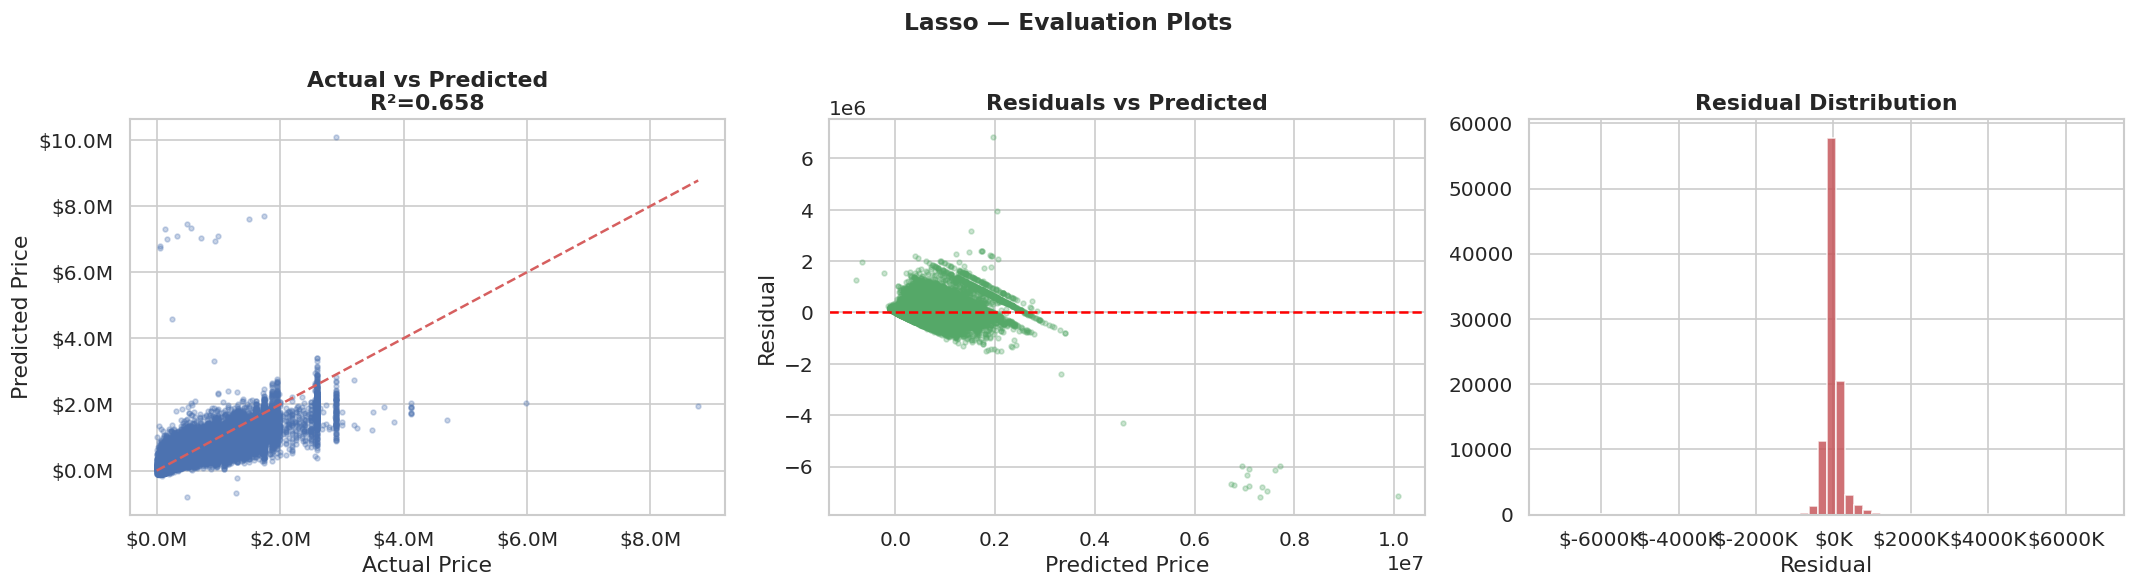

R²   : 0.6584
MAE  : $136,744
RMSE : $227,213
MAPE : 5213.66%


In [68]:
# ── Prediction vs Actual & Residual Plots ─────────────────────────────────────
# Use a holdout split for visualization
Xtr2, Xval2, ytr2, yval2 = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)
final_model.fit(Xtr2, ytr2)
preds_val = final_model.predict(Xval2)

residuals = yval2 - preds_val

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(yval2, preds_val, alpha=0.3, s=8, color='#4C72B0')
mn, mx = yval2.min(), yval2.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Price'); axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted\nR²={r2_score(yval2, preds_val):.3f}', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

# Residuals vs Predicted
axes[1].scatter(preds_val, residuals, alpha=0.3, s=8, color='#55A868')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Price'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')

# Error distribution
axes[2].hist(residuals, bins=60, color='#C44E52', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Residual'); axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

plt.suptitle(f'{best_model_name} — Evaluation Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Metrics
print(f'R²   : {r2_score(yval2, preds_val):.4f}')
print(f'MAE  : ${mean_absolute_error(yval2, preds_val):,.0f}')
print(f'RMSE : ${np.sqrt(mean_squared_error(yval2, preds_val)):,.0f}')
mape_val = np.mean(np.abs((yval2 - preds_val) / yval2.clip(lower=1))) * 100
print(f'MAPE : {mape_val:.2f}%')

---
## 19. SHAP Explainability

In [ ]:
# ── SHAP Global Feature Importance ───────────────────────────────────────────
explainer   = shap.TreeExplainer(final_model)
sample_size = min(2000, len(X_scaled))
X_sample    = X_scaled.sample(sample_size, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                  max_display=20, show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── SHAP Beeswarm Plot ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP Summary (Beeswarm) — Feature Impact on Price', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── SHAP Waterfall for a single prediction ────────────────────────────────────
idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx],
        feature_names=X_sample.columns.tolist()
    ),
    max_display=15
)

---
## 20. Save Artifacts

In [70]:
import json

# Refit final model on ALL data
final_model.fit(X_scaled, y)

# ── Save model ────────────────────────────────────────────────────────────────
joblib.dump(final_model, 'artifacts/trained_model.joblib')
print('✅ Saved: artifacts/trained_model.joblib')

# ── Save scaler ───────────────────────────────────────────────────────────────
joblib.dump(scaler, 'artifacts/scaler.joblib')
print('✅ Saved: artifacts/scaler.joblib')

# ── Save feature info ─────────────────────────────────────────────────────────
feature_info = {
    'feature_cols'  : FEATURE_COLS,
    'high_card_cols': HIGH_CARD_COLS,
    'low_card_cols' : LOW_CARD_COLS,
    'num_cols'      : NUM_COLS,
    'miss_ind_cols' : MISS_IND_COLS,
    'target'        : TARGET,
    'n_features'    : len(FEATURE_COLS),
}
joblib.dump(feature_info, 'artifacts/feature_info.joblib')
print('✅ Saved: artifacts/feature_info.joblib')

# ── Save metrics CSV ──────────────────────────────────────────────────────────
pd.DataFrame(all_results).to_csv('artifacts/metrics.csv', index=False)
print('✅ Saved: artifacts/metrics.csv')

# ── Save ZIP lookup table ─────────────────────────────────────────────────────
zip_df.to_csv('artifacts/zip_lookup.csv', index=False)
print('✅ Saved: artifacts/zip_lookup.csv')

print('\n🎉 All artifacts saved to artifacts/')

✅ Saved: artifacts/trained_model.joblib
✅ Saved: artifacts/scaler.joblib
✅ Saved: artifacts/feature_info.joblib
✅ Saved: artifacts/metrics.csv
✅ Saved: artifacts/zip_lookup.csv

🎉 All artifacts saved to artifacts/


---
## 22. Project Summary

In [ ]:
best_row = final_results.loc[final_results['R2'].idxmax()]

print('='*60)
print('  🏠 REAL ESTATE PRICE PREDICTION — FINAL SUMMARY')
print('='*60)
print(f'  Dataset rows          : {len(df):,}')
print(f'  Features used         : {len(FEATURE_COLS)}')
print(f'  External ZIP records  : {len(zip_df):,}')
print(f'  Validation strategy   : GroupKFold (zip_code, {N_SPLITS} folds)')
print('─'*60)
print(f'  Best model            : {final_results["R2"].idxmax()}')
print(f'  R²                   : {best_row["R2"]:.4f}')
print(f'  MAE                  : ${best_row["MAE"]:,.0f}')
print(f'  RMSE                 : ${best_row["RMSE"]:,.0f}')
print(f'  MAPE                 : {best_row["MAPE"]:.2f}%')
print('─'*60)
print('  Artifacts saved:')
print('    artifacts/trained_model.joblib')
print('    artifacts/scaler.joblib')
print('    artifacts/feature_info.joblib')
print('    artifacts/metrics.csv')
print('    artifacts/zip_lookup.csv')
print('    artifacts/streamlit_app.py')
print('='*60)